<center>
<div style="background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%);
            padding: 12px 40px;
            border-radius: 8px;
            border-left: 4px solid #00d4ff;
            box-shadow: 0 4px 20px rgba(0, 212, 255, 0.15);
            margin: 15px 0;
            width: 100%;
            box-sizing: border-box;">
    <h1 style="color: #00d4ff; 
               font-family: 'Consolas', 'Courier New', monospace; 
               font-size: 28px; 
               font-weight: 700; 
               margin: 0;
               letter-spacing: 1px;
               text-shadow: 0 0 20px rgba(0, 212, 255, 0.3);
               text-align: center;">
        🎯 DATA_GENERATION
    </h1>
    <p style="color: rgba(255,255,255,0.6); 
              font-size: 13px; 
              margin: 4px 0 0 0;
              font-family: 'Consolas', 'Courier New', monospace;
              letter-spacing: 0.5px;
              text-align: center;">
        synthetic_data · visualization · geometry
    </p>
</div>
</center>

# Синтетические данные для тестирования ядер SVM

В этом ноутбуке для каждого из четырёх ядер SVM генерируется **синтетический датасет**,
на котором хорошо видна причина, по которой именно это ядро для него подходит.

Для каждого ядра сделано два шага:

1. **Исходные данные** — как они выглядят "как есть", в изначальном пространстве признаков.
2. **Преобразование (feature mapping φ(x))** — показывает, во что неявно "превращает" данные соответствующее ядро,
   и почему после этого преобразования классы становится можно разделить **линейно**.

> На этом этапе сам SVM ещё не обучается — только генерация и визуализация данных.

## Содержание
1. **Линейное ядро**
2. **Гауссово (RBF) ядро**
3. **Полиномиальное ядро**
4. **Сигмоидное ядро**
5. **Сводная таблица и советы по оформлению**


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (нужен для projection='3d')

from sklearn.datasets import (
    make_classification,
    make_blobs,
    make_circles,
    make_gaussian_quantiles,
)

# ---- единый стиль оформления для всех графиков ----
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
COLORS = {0: "#1434D1", 1: "#EC1C1C"}  # синий / оранжевый — не зависят от красно-зелёной слепоты


## 1. Линейное ядро

$$K(x, x') = x \cdot x'$$

Линейное ядро ничего не преобразует — оно работает прямо в исходном пространстве.
Значит датасет должен быть **линейно разделим уже в исходных координатах**.

**Метод sklearn:** `make_classification` с `n_clusters_per_class=1` и достаточным `class_sep`
(альтернатива — `make_blobs` с 2 центрами и небольшим `cluster_std`).


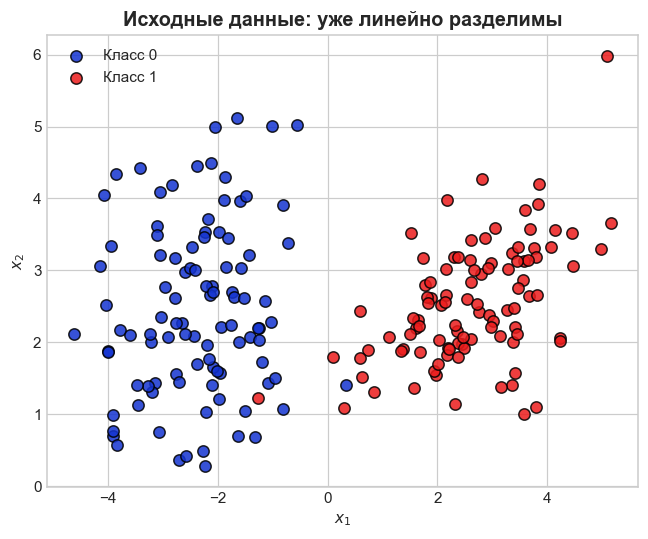

In [3]:
X_lin, y_lin = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.5,       # чем больше - тем чище разрыв между классами
    n_classes=2,
    random_state=RANDOM_STATE,
)

fig, ax = plt.subplots(figsize=(6, 5))
for cls, color in COLORS.items():
    mask = y_lin == cls
    ax.scatter(X_lin[mask, 0], X_lin[mask, 1], c=color, edgecolor='k',
               s=55, alpha=0.85, label=f'Класс {cls}')

ax.set_title('Исходные данные: уже линейно разделимы')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.tight_layout()
plt.show()


**Преобразование:** для линейного ядра φ(x) = x — преобразование тождественное,
никакой новой размерности не нужно. Ниже — чисто иллюстративная линия
(перпендикуляр к отрезку между центрами классов), просто чтобы визуально
показать, что классы можно развести прямой линией.


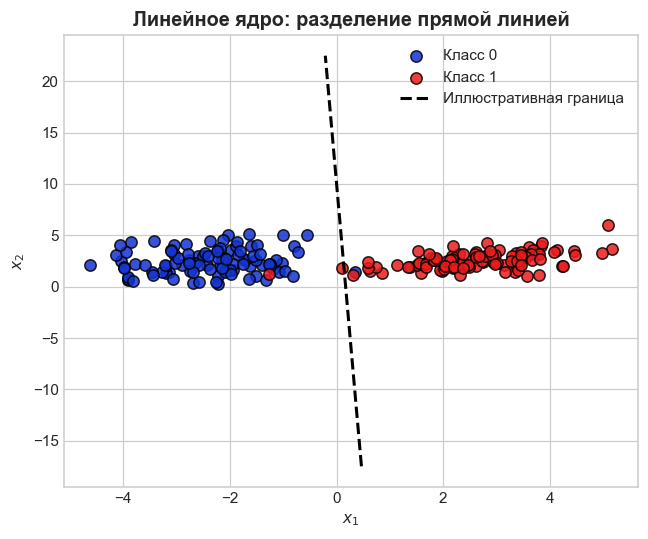

In [4]:
c0 = X_lin[y_lin == 0].mean(axis=0)
c1 = X_lin[y_lin == 1].mean(axis=0)
mid = (c0 + c1) / 2
direction = c1 - c0
normal = np.array([-direction[1], direction[0]])  # перпендикуляр к отрезку центров

t = np.linspace(-4, 4, 2)
line_pts = mid + np.outer(t, normal)

fig, ax = plt.subplots(figsize=(6, 5))
for cls, color in COLORS.items():
    mask = y_lin == cls
    ax.scatter(X_lin[mask, 0], X_lin[mask, 1], c=color, edgecolor='k',
               s=55, alpha=0.85, label=f'Класс {cls}')
ax.plot(line_pts[:, 0], line_pts[:, 1], 'k--', lw=2, label='Иллюстративная граница')
ax.set_title('Линейное ядро: разделение прямой линией')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.tight_layout()
plt.show()


## 2. Гауссово (RBF) ядро

$$K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)$$

Классический пример — две концентрические окружности: в 2D они линией
не разделяются, а после добавления координаты "расстояние от центра"
данные превращаются в параболоид (конус), и классы легко разделяются плоскостью.

**Метод sklearn:** `make_circles` — генерирует два вложенных круга разных классов.


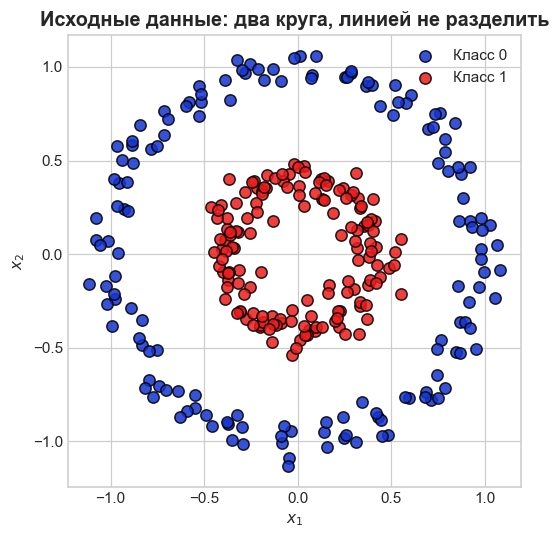

In [5]:
X_rbf, y_rbf = make_circles(
    n_samples=300,
    noise=0.06,
    factor=0.4,          # отношение радиуса внутренней окружности к внешней
    random_state=RANDOM_STATE,
)

fig, ax = plt.subplots(figsize=(6, 5))
for cls, color in COLORS.items():
    mask = y_rbf == cls
    ax.scatter(X_rbf[mask, 0], X_rbf[mask, 1], c=color, edgecolor='k',
               s=55, alpha=0.85, label=f'Класс {cls}')
ax.set_title('Исходные данные: два круга, линией не разделить')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()


**Преобразование:** $\varphi(x_1, x_2) = (x_1,\, x_2,\, x_1^2 + x_2^2)$.

Это ровно то, что неявно "умеет" RBF-ядро — превратить окружности в
параболоид, круги "поднимаются" на разную высоту по третьей оси и
разделяются горизонтальной плоскостью.


<blockquote style="
    border-left: 6px solid #00d4ff;
    border-radius: 0 12px 12px 0;
    padding: 20px 28px;
    margin: 24px 0;
    font-family: 'Segoe UI', 'Consolas', monospace;
    box-shadow: 0 4px 20px rgba(0, 212, 255, 0.08);
">
    <p style="font-size: 22px; font-weight: 700; color: #00d4ff; margin: 0 0 16px 0;">
        🧠 Интересный момент с разделяющей линией
</p>
<p Как нам для наглядности показать среднюю разделяющую линию?
</p> Наша задача найти третью ось. Для этого мы пользуемся формулой z = x₁² + x₂²
<p Теперь как для наглядности найти разделяющую плоскость?
</p> Мы знаем то насколько наши точки поднялись по оси Z, мы эту инфу знаем по каждой точке.
</p> Найдем сумму расстояний по всем точкам (и класса 1 и класса 0), берем расстояния от 0 по оси Z и найдем среднее
    </p>
</blockquote>

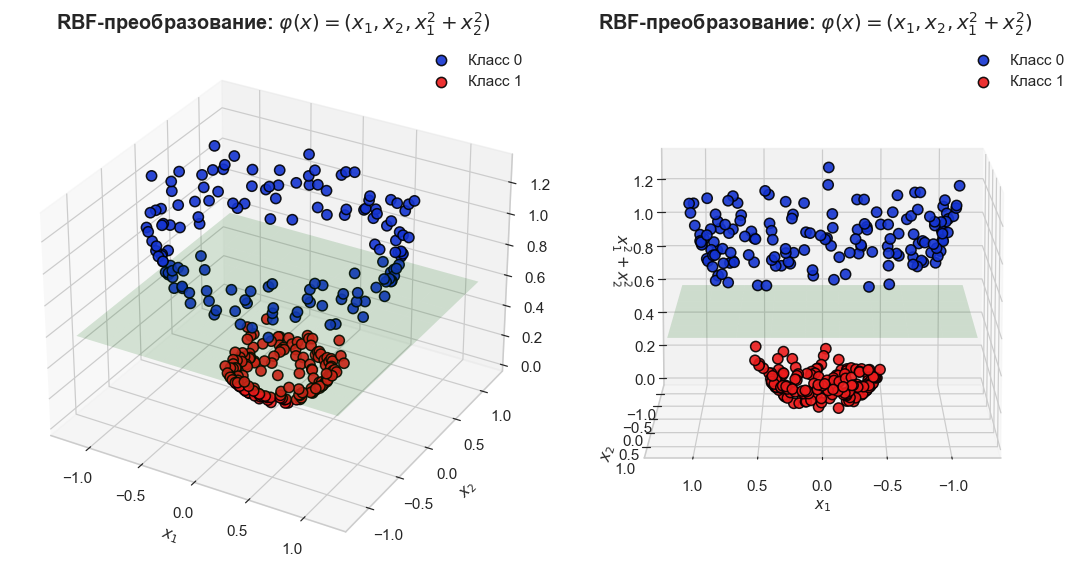

In [6]:
z_rbf = X_rbf[:, 0] ** 2 + X_rbf[:, 1] ** 2
threshold = z_rbf.mean()  # чисто иллюстративный порог для разделяющей плоскости

# Сетка для плоскости — одна на оба графика, пересчитывать дважды незачем
xx, yy = np.meshgrid(np.linspace(-1.2, 1.2, 10), np.linspace(-1.2, 1.2, 10))

# Два раза записывать в график данные руками — лень, поэтому обернули в функцию
# и вызываем её для каждого ракурса (elev, azim) через view_init
def plot_rbf_3d(ax, elev, azim):
    # Два раза запиcываем в график данные
    # С помощью маски закидваем те что имеют класс 0 потом 1
    # тут по идее можно два раза отдельно сделать scatter (напихать график),
    # но мы делаем с помощью цикла, потому что мы крутые. параметры смотрите в инете)
    # Ну ладно вот они)
    # ax.scatter(X, Y, Z,
    #            c=color,           # цвет точек
    #            edgecolor='k',     # цвет обводки
    #            s=45,              # размер точек
    #            alpha=0.9,         # прозрачность
    #            label=f'Класс {cls}')  # подпись для легенды
    for cls, color in COLORS.items():
        mask = y_rbf == cls
        ax.scatter(X_rbf[mask, 0], X_rbf[mask, 1], z_rbf[mask],
                   c=color, edgecolor='k', s=45, alpha=0.9, label=f'Класс {cls}')

    # иллюстративная разделяющая плоскость z = threshold
    ax.plot_surface(xx, yy, np.full_like(xx, threshold), alpha=0.15, color='green')

    ax.set_title(r'RBF-преобразование: $\varphi(x)=(x_1, x_2, x_1^2+x_2^2)$')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$x_1^2+x_2^2$')
    ax.view_init(elev, azim)  # elev, azim задают угол обзора (вместо ax.view_init(0, 90))
    ax.legend()

# Создаем холст с двумя графиками
fig = plt.figure(figsize=(10, 8))

# 1 график с видом сверху (дефолтный ракурс matplotlib)
ax1 = fig.add_subplot(121, projection='3d')
plot_rbf_3d(ax1, elev=30, azim=-60)

# создание 2 графика с видом с боку
ax2 = fig.add_subplot(122, projection='3d')
plot_rbf_3d(ax2, elev=10, azim=90)

plt.tight_layout()
plt.show()

## 3. Полиномиальное ядро

$$K(x, x') = (\gamma\, x \cdot x' + c)^d$$

1D-аналог предыдущей истории: данные лежат на одной оси, класс зависит от
того, насколько точка близка к центру или удалена от него (внутренний
"сгусток" против "хвостов"). В 1D это линией (точкой-порогом с одной
стороны) не разделить так же чисто, зато после перехода в 2D через
$x \to (x, x^2)$ получается парабола, которая разделяется прямой.

**Метод sklearn:** `make_gaussian_quantiles` с `n_features=1` — генерирует
одномерные точки и размечает их по квантилям расстояния от центра
распределения (то есть ровно "средние" и "крайние" значения).


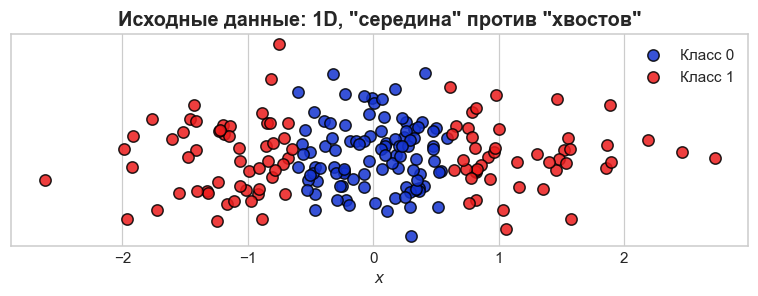

In [7]:
X_poly, y_poly = make_gaussian_quantiles(
    n_samples=200,
    n_features=1,
    n_classes=2,
    random_state=RANDOM_STATE,
)
x_poly = X_poly[:, 0]

fig, ax = plt.subplots(figsize=(7, 2.8))
rng = np.random.default_rng(RANDOM_STATE)
jitter = rng.normal(0, 0.02, size=x_poly.shape)  # только для наглядности по Y

for cls, color in COLORS.items():
    mask = y_poly == cls
    ax.scatter(x_poly[mask], jitter[mask], c=color, edgecolor='k',
               s=55, alpha=0.85, label=f'Класс {cls}')

ax.set_title('Исходные данные: 1D, "середина" против "хвостов"')
ax.set_xlabel('$x$')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()


**Преобразование:** $\varphi(x) = (x,\, x^2)$ — именно так работает полиномиальное
ядро степени 2. Одномерная прямая "сворачивается" в параболу, и классы
(центр / края) расходятся по оси $x^2$.


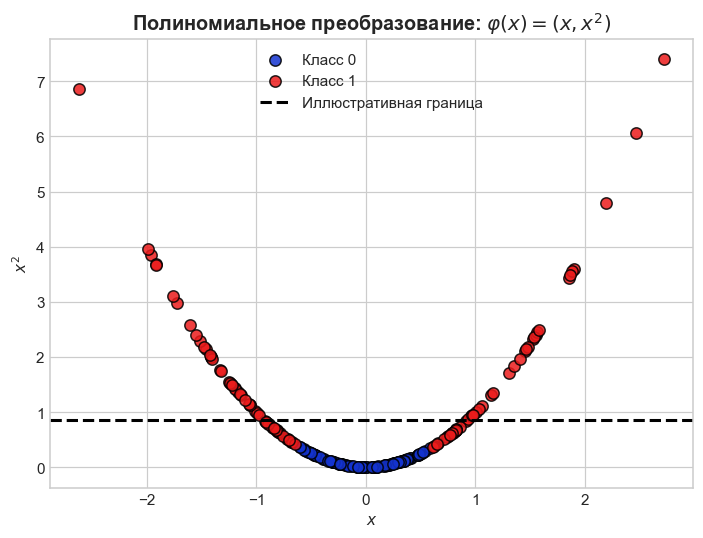

In [9]:
z_poly = x_poly ** 2
threshold_poly = z_poly.mean()

fig, ax = plt.subplots(figsize=(6.5, 5))
for cls, color in COLORS.items():
    mask = y_poly == cls
    ax.scatter(x_poly[mask], z_poly[mask], c=color, edgecolor='k',
               s=55, alpha=0.85, label=f'Класс {cls}')

ax.axhline(threshold_poly, color='k', ls='--', lw=2, label='Иллюстративная граница')
ax.set_title(r'Полиномиальное преобразование: $\varphi(x)=(x, x^2)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$x^2$')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Сигмоидное ядро

$$K(x, x') = \tanh(\gamma\, x \cdot x' + r)$$

Сигмоидное ядро делает SVM похожим на нейрон с $\tanh$-активацией, поэтому
его классический "тест на прочность" — **XOR**: точки в четырёх
квадрантах, где класс зависит от совпадения/несовпадения знаков координат.
Ни линия, ни простая парабола такую разметку не разделяют.

**Метод sklearn:** прямого генератора XOR нет, поэтому берём `make_blobs`
с 4 центрами по вершинам квадрата и вручную размечаем классы по правилу XOR
(альтернатива — `make_classification(..., n_clusters_per_class=2)`, где
кластеры одного класса тоже разносятся по разным "углам" пространства признаков).


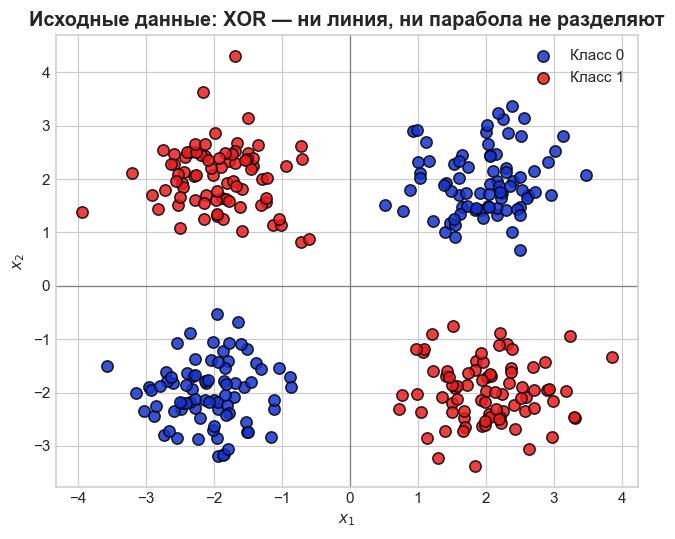

In [10]:
centers = [(-2, -2), (-2, 2), (2, -2), (2, 2)]  # четыре квадранта
X_xor, cluster_id = make_blobs(
    n_samples=320,
    centers=centers,
    cluster_std=0.6,
    random_state=RANDOM_STATE,
)

# XOR-разметка: одинаковые знаки x1,x2 -> класс 0, разные знаки -> класс 1
# cluster_id: 0=(-,-), 1=(-,+), 2=(+,-), 3=(+,+) 
y_xor = np.where(np.isin(cluster_id, [0, 3]), 0, 1)

fig, ax = plt.subplots(figsize=(6, 5))
for cls, color in COLORS.items():
    mask = y_xor == cls
    ax.scatter(X_xor[mask, 0], X_xor[mask, 1], c=color, edgecolor='k',
               s=55, alpha=0.85, label=f'Класс {cls}')
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)
ax.set_title('Исходные данные: XOR — ни линия, ни парабола не разделяют')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()
plt.tight_layout()
plt.show()


**Преобразование:** классический трюк, который "линеаризует" XOR —
добавить признак произведения $\varphi(x_1, x_2) = (x_1,\, x_2,\, x_1 x_2)$.
Знак $x_1 x_2$ идеально совпадает с классом, поэтому в новой оси данные
разделяет плоскость $z = 0$.

Это не точная копия того, что делает tanh-ядро (там пространство неявное и
устроено сложнее), но хорошо показывает саму идею: нужен именно
**нелинейный, "перекрёстный"** признак — что и умеет находить нейрон с
sigmoid/tanh-активацией.


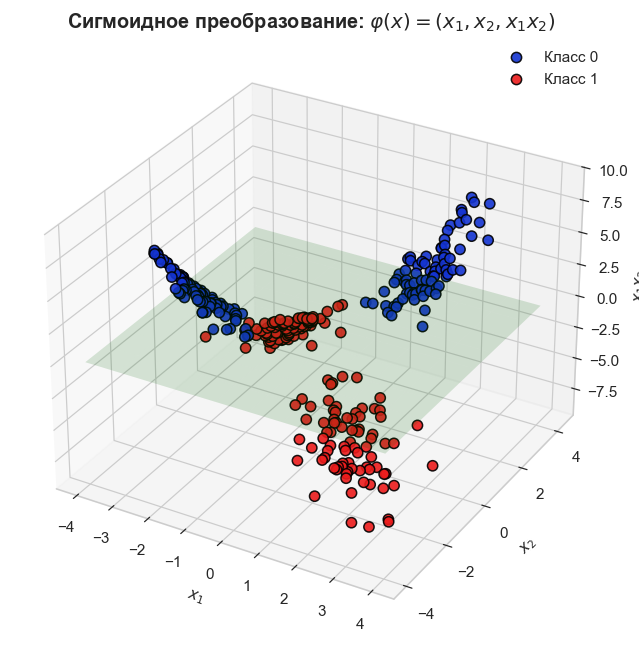

In [12]:
z_xor = X_xor[:, 0] * X_xor[:, 1]

fig = plt.figure(figsize=(7.5, 6))
ax = fig.add_subplot(111, projection='3d')

for cls, color in COLORS.items():
    mask = y_xor == cls
    ax.scatter(X_xor[mask, 0], X_xor[mask, 1], z_xor[mask],
               c=color, edgecolor='k', s=45, alpha=0.9, label=f'Класс {cls}')

xx, yy = np.meshgrid(np.linspace(-4, 4, 10), np.linspace(-4, 4, 10))
ax.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.15, color='green')

ax.set_title(r'Сигмоидное преобразование: $\varphi(x)=(x_1, x_2, x_1 x_2)$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_1 x_2$')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Сводная таблица и советы по оформлению

| Ядро | Формула | Метод sklearn | Проблема исходных данных | Преобразование φ(x) |
|---|---|---|---|---|
| Линейное | $x\cdot x'$ | `make_classification` (1 кластер/класс) | нет — уже разделимо | $\varphi(x)=x$ |
| RBF (Гаусс) | $\exp(-\gamma\lVert x-x'\rVert^2)$ | `make_circles` | круги друг в друге | $(x_1,x_2,x_1^2+x_2^2)$ |
| Полиномиальное | $(\gamma x\cdot x'+c)^d$ | `make_gaussian_quantiles` (1D) | центр против краёв | $(x, x^2)$ |
| Сигмоидное | $\tanh(\gamma x\cdot x'+r)$ | `make_blobs` + разметка XOR | XOR, не Мерсеровское ядро | $(x_1,x_2,x_1x_2)$ |
